In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("students.csv")

df.head()

,student_id,name,gender,study_hours,sleep_hours,attendance,assignments_completed,practice_tests,final_marks
0,1,Aarav,Male,2.5,7.0,78,6,2,68
1,2,Ananya,Female,4.0,7.5,88,8,4,82
2,3,Rohan,Male,1.5,6.0,62,4,1,54
3,4,Priya,Female,5.0,8.0,92,9,5,90
4,5,Kabir,Male,3.0,6.5,75,7,3,70


In [5]:
connection = sqlite3.connect("student_analytics.db")

In [6]:
df.to_sql("students", connection, if_exists="replace", index=False)

15

In [8]:
df = pd.read_sql_query("SELECT * FROM students", connection)

df.head()

,student_id,name,gender,study_hours,sleep_hours,attendance,assignments_completed,practice_tests,final_marks
0,1,Aarav,Male,2.5,7.0,78,6,2,68
1,2,Ananya,Female,4.0,7.5,88,8,4,82
2,3,Rohan,Male,1.5,6.0,62,4,1,54
3,4,Priya,Female,5.0,8.0,92,9,5,90
4,5,Kabir,Male,3.0,6.5,75,7,3,70


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             15 non-null     int64  
 1   name                   15 non-null     object 
 2   gender                 15 non-null     object 
 3   study_hours            15 non-null     float64
 4   sleep_hours            15 non-null     float64
 5   attendance             15 non-null     int64  
 6   assignments_completed  15 non-null     int64  
 7   practice_tests         15 non-null     int64  
 8   final_marks            15 non-null     int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 1.2+ KB


In [10]:
df.describe()

,student_id,study_hours,sleep_hours,attendance,assignments_completed,practice_tests,final_marks
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,8.000000,3.220000,6.866667,77.266667,6.733333,3.066667,71.800000
std,4.472136,1.312685,0.766874,11.786594,2.051712,1.579632,14.487433
min,1.000000,1.000000,5.500000,55.000000,3.000000,1.000000,45.000000
25%,4.500000,2.250000,6.250000,71.000000,5.500000,2.000000,63.000000
50%,8.000000,3.200000,7.000000,79.000000,7.000000,3.000000,72.000000
75%,11.500000,4.100000,7.500000,85.500000,8.000000,4.000000,83.000000
max,15.000000,5.500000,8.000000,95.000000,10.000000,6.000000,94.000000


In [11]:
df.isnull().sum()

student_id               0
name                     0
gender                   0
study_hours              0
sleep_hours              0
attendance               0
assignments_completed    0
practice_tests           0
final_marks              0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
def marks_category(marks):
    if marks >= 85:
        return "Excellent"
    elif marks >= 70:
        return "Good"
    elif marks >= 50:
        return "Average"
    else:
        return "Needs Improvement"

df["performance_category"] = df["final_marks"].apply(marks_category)

df.head()

,student_id,name,gender,study_hours,sleep_hours,attendance,assignments_completed,practice_tests,final_marks,performance_category
0,1,Aarav,Male,2.5,7.0,78,6,2,68,Average
1,2,Ananya,Female,4.0,7.5,88,8,4,82,Good
2,3,Rohan,Male,1.5,6.0,62,4,1,54,Average
3,4,Priya,Female,5.0,8.0,92,9,5,90,Excellent
4,5,Kabir,Male,3.0,6.5,75,7,3,70,Good


In [15]:
def attendance_group(attendance):
    if attendance >= 85:
        return "High Attendance"
    elif attendance >= 70:
        return "Medium Attendance"
    else:
        return "Low Attendance"

df["attendance_group"] = df["attendance"].apply(attendance_group)

df.head()

,student_id,name,gender,study_hours,sleep_hours,attendance,assignments_completed,practice_tests,final_marks,performance_category,attendance_group
0,1,Aarav,Male,2.5,7.0,78,6,2,68,Average,Medium Attendance
1,2,Ananya,Female,4.0,7.5,88,8,4,82,Good,High Attendance
2,3,Rohan,Male,1.5,6.0,62,4,1,54,Average,Low Attendance
3,4,Priya,Female,5.0,8.0,92,9,5,90,Excellent,High Attendance
4,5,Kabir,Male,3.0,6.5,75,7,3,70,Good,Medium Attendance


In [16]:
average_marks = np.mean(df["final_marks"])
median_marks = np.median(df["final_marks"])
highest_marks = np.max(df["final_marks"])
lowest_marks = np.min(df["final_marks"])
marks_std = np.std(df["final_marks"])

print("Average Marks:", average_marks)
print("Median Marks:", median_marks)
print("Highest Marks:", highest_marks)
print("Lowest Marks:", lowest_marks)
print("Standard Deviation:", marks_std)

Average Marks: 71.8
Median Marks: 72.0
Highest Marks: 94
Lowest Marks: 45
Standard Deviation: 13.996189957746836


In [17]:
top_5_students = df.sort_values(by="final_marks", ascending=False).head(5)

top_5_students

,student_id,name,gender,study_hours,sleep_hours,attendance,assignments_completed,practice_tests,final_marks,performance_category,attendance_group
9,10,Isha,Female,5.5,8.0,95,10,6,94,Excellent,High Attendance
3,4,Priya,Female,5.0,8.0,92,9,5,90,Excellent,High Attendance
12,13,Kunal,Male,4.2,7.5,86,9,5,85,Excellent,High Attendance
5,6,Meera,Female,4.5,7.0,85,8,4,84,Good,High Attendance
1,2,Ananya,Female,4.0,7.5,88,8,4,82,Good,High Attendance


In [18]:
gender_analysis = df.groupby("gender")["final_marks"].mean()

gender_analysis

gender
Female    77.714286
Male      66.625000
Name: final_marks, dtype: float64

In [19]:
category_analysis = df.groupby("performance_category")["final_marks"].mean()

category_analysis

performance_category
Average              60.000000
Excellent            89.666667
Good                 77.166667
Needs Improvement    45.000000
Name: final_marks, dtype: float64

In [20]:
attendance_analysis = df.groupby("attendance_group")["final_marks"].mean()

attendance_analysis

attendance_group
High Attendance      87.000000
Low Attendance       52.750000
Medium Attendance    71.833333
Name: final_marks, dtype: float64

In [21]:
study_analysis = df.groupby("performance_category")["study_hours"].mean()

study_analysis

performance_category
Average              2.120000
Excellent            4.900000
Good                 3.666667
Needs Improvement    1.000000
Name: study_hours, dtype: float64

In [22]:
practice_test_analysis = df.groupby("practice_tests")["final_marks"].mean()

practice_test_analysis

practice_tests
1    50.333333
2    64.666667
3    72.666667
4    81.666667
5    87.500000
6    94.000000
Name: final_marks, dtype: float64

In [23]:
numeric_columns = [
    "study_hours",
    "sleep_hours",
    "attendance",
    "assignments_completed",
    "practice_tests",
    "final_marks"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,study_hours,sleep_hours,attendance,assignments_completed,practice_tests,final_marks
study_hours,1.000000,0.893333,0.968657,0.978106,0.967280,0.988040
sleep_hours,0.893333,1.000000,0.909041,0.883737,0.862850,0.900730
attendance,0.968657,0.909041,1.000000,0.977873,0.938903,0.990042
assignments_completed,0.978106,0.883737,0.977873,1.000000,0.975610,0.990540
practice_tests,0.967280,0.862850,0.938903,0.975610,1.000000,0.965082
final_marks,0.988040,0.900730,0.990042,0.990540,0.965082,1.000000


In [24]:
marks_relationship = correlation_matrix["final_marks"].sort_values(ascending=False)

marks_relationship

final_marks              1.000000
assignments_completed    0.990540
attendance               0.990042
study_hours              0.988040
practice_tests           0.965082
sleep_hours              0.900730
Name: final_marks, dtype: float64

In [25]:
column_list = list(df.columns)

In [26]:
summary_dictionary = {
    "average_marks": average_marks,
    "highest_marks": highest_marks,
    "lowest_marks": lowest_marks,
    "median_marks": median_marks
}

In [27]:
grade_ranges = (
    ("Excellent", "85 and above"),
    ("Good", "70 to 84"),
    ("Average", "50 to 69"),
    ("Needs Improvement", "Below 50")
)


In [28]:
unique_categories = set(df["performance_category"])

In [29]:
print("Columns:", column_list)
print("Summary:", summary_dictionary)
print("Grade Ranges:", grade_ranges)
print("Unique Categories:", unique_categories)

Columns: ['student_id', 'name', 'gender', 'study_hours', 'sleep_hours', 'attendance', 'assignments_completed', 'practice_tests', 'final_marks', 'performance_category', 'attendance_group']
Summary: {'average_marks': np.float64(71.8), 'highest_marks': 94, 'lowest_marks': 45, 'median_marks': np.float64(72.0)}
Grade Ranges: (('Excellent', '85 and above'), ('Good', '70 to 84'), ('Average', '50 to 69'), ('Needs Improvement', 'Below 50'))
Unique Categories: {'Good', 'Average', 'Excellent', 'Needs Improvement'}


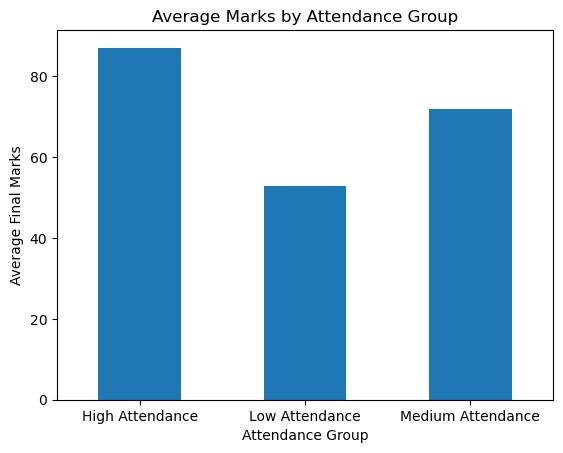

In [30]:
attendance_analysis.plot(kind="bar")

plt.title("Average Marks by Attendance Group")
plt.xlabel("Attendance Group")
plt.ylabel("Average Final Marks")
plt.xticks(rotation=0)
plt.show()

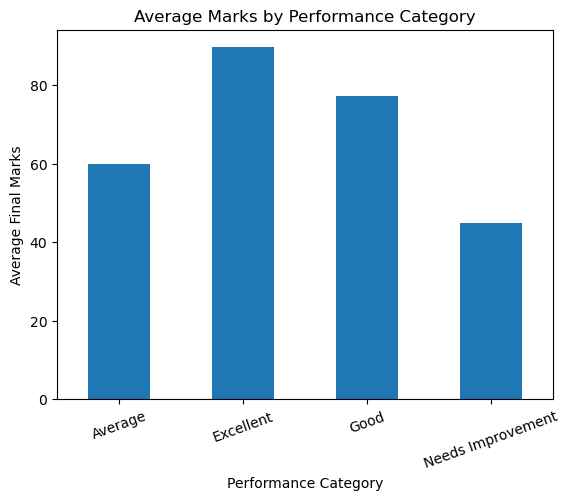

In [31]:
category_analysis.plot(kind="bar")

plt.title("Average Marks by Performance Category")
plt.xlabel("Performance Category")
plt.ylabel("Average Final Marks")
plt.xticks(rotation=20)
plt.show()

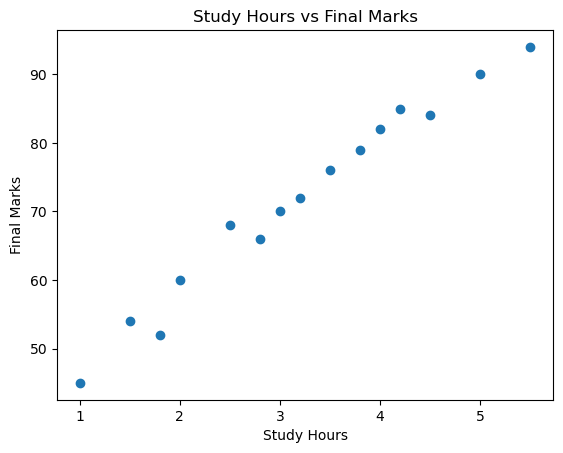

In [32]:
plt.scatter(df["study_hours"], df["final_marks"])

plt.title("Study Hours vs Final Marks")
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.show()

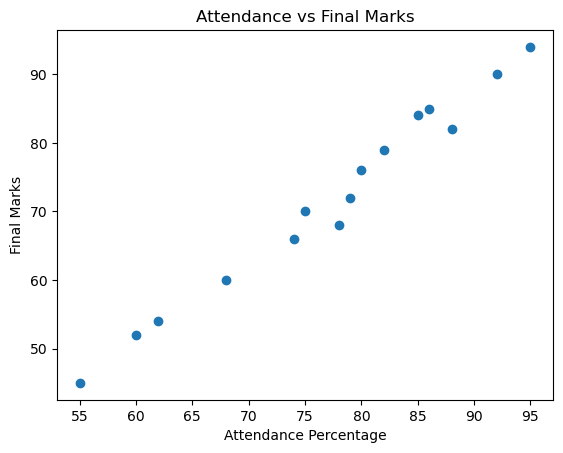

In [33]:
plt.scatter(df["attendance"], df["final_marks"])

plt.title("Attendance vs Final Marks")
plt.xlabel("Attendance Percentage")
plt.ylabel("Final Marks")
plt.show()

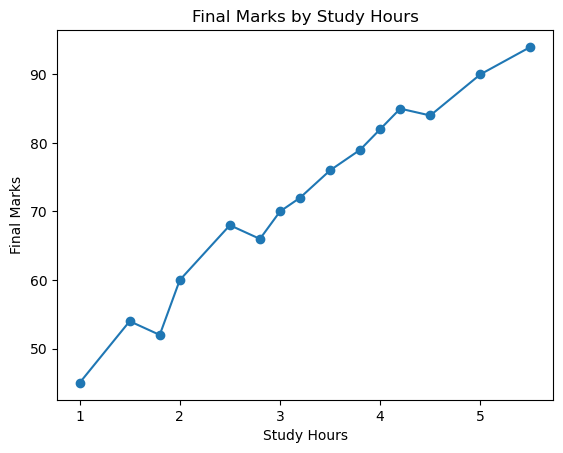

In [34]:
sorted_df = df.sort_values(by="study_hours")

plt.plot(sorted_df["study_hours"], sorted_df["final_marks"], marker="o")

plt.title("Final Marks by Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.show()

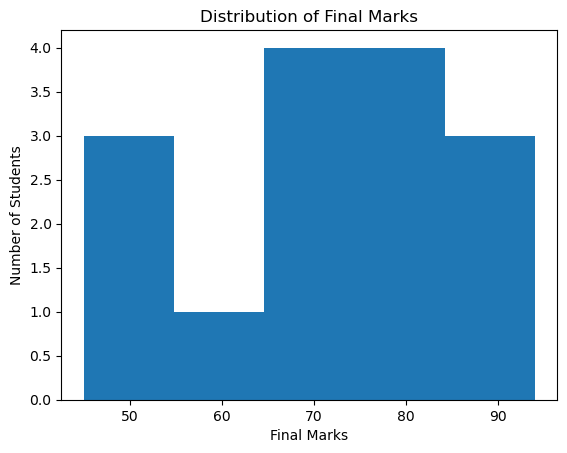

In [35]:
plt.hist(df["final_marks"], bins=5)

plt.title("Distribution of Final Marks")
plt.xlabel("Final Marks")
plt.ylabel("Number of Students")
plt.show()

In [37]:
connection.close()